# Detecting Credit Card Fraud using Unsupervised Learning #


Credit card fraud is an issue that impacts every business that takes credit card payments as well as every credit card holder. In 2023, credit card fraud losses totaled 34 billion dollars. Credit card processing companies and retailers who process high volumes of transactions require the ability to quickly identify fraudulent credit cards to cancel the card to reduce losses.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.ma.extras import column_stack
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import time
from sklearn.metrics import classification_report,roc_curve, auc
%matplotlib inline

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score,roc_curve, auc





**The Data**

I will be analyzing a dataset of 284K credit card transactions with 30 features. The dataset was downloaded from kaggle.com and was compiled through a collaboration of Worldline and the Machine Learning Group (http://mlg.ulb.ac.be) of ULB (Université Libre de Bruxelles). (1)

**The Problem**

Businesses need to quickly identify fraudulent credit card transactions to quickly take mitigating action. I will be using unsupervised learning tools to identify anomalies in the data that indicate fraud.


In [14]:
#load zip file view records, check df info
# to run this code you must download the dataset and store it in a data/ directory in this project
# data can be downloaded here:
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data


df = pd.read_csv('data/creditcard.csv.zip')


# Unsupervised Learning Methods #

I will be using two unsupervised learning methods that were not covered in this session, Local Outlier Factor (LOF) and Isolated Forest.
These method are particularly good at identifying anomalies within datasets. The model will look for outliers by measuring the distance between neighboring datapoints and measuring the density of data neighborhoods. Sparse neighborhoods that are relatively more distant are identified as outliers and potential fraud. I will then measure the percentage of fraudulent transactions found in the outlier group vs. the main group to determine if the model has been successful in identifying fraud.

# Exploratory Data Analysis (EDA) #

I will be running the standard EDA procedures on this data, looking for missing values, dropping unnecessary columns and inspecting the data to attempt to identify other methods to pre-process the data for the best results.None

## EDA STEP ONE: VIEW DATA ##

view the shape of the data and the field names and types

check balance of fraud to non-fraud

check for empty records



In [15]:
df.info()

print("\r\nFraud count:", df['Class'].sum())

print("\r\nMissing values:\n", df.isnull().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## EDA STEP TWO: CLEAN DATA ##

drop useless columns

modify columns to optimize for model



In [16]:
# drop time just shows sequence of transactions
df = df.drop(['Time'], axis=1)

# feature engineering addressing Amount
df['Rounded'] = df.Amount.apply(lambda x: int(round(x)))
print(df['Amount'].head())
print(df['Rounded'].head())

# drop Amount field since Rounded has replaced it


0    149.62
1      2.69
2    378.66
3    123.50
4     69.99
Name: Amount, dtype: float64
0    150
1      3
2    379
3    124
4     70
Name: Rounded, dtype: int64


Text(0.5, 1.0, 'Class Distribution: Fraud vs Non-Fraud')

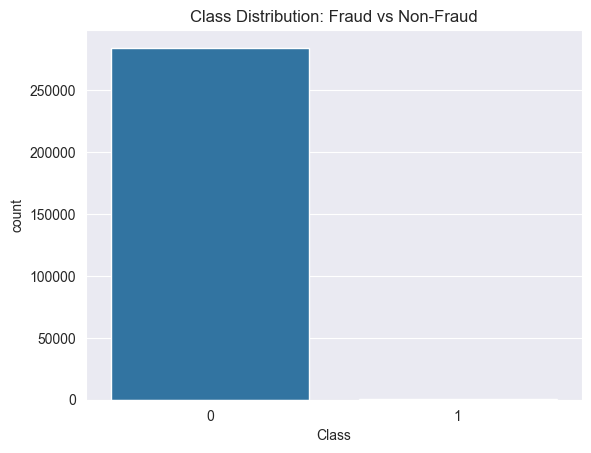

In [17]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution: Fraud vs Non-Fraud")

## Highly unbalanced data ##

Because the record count of the data is so high and the fraudulent transactions are so low, the fraud records do not even register in the chart.


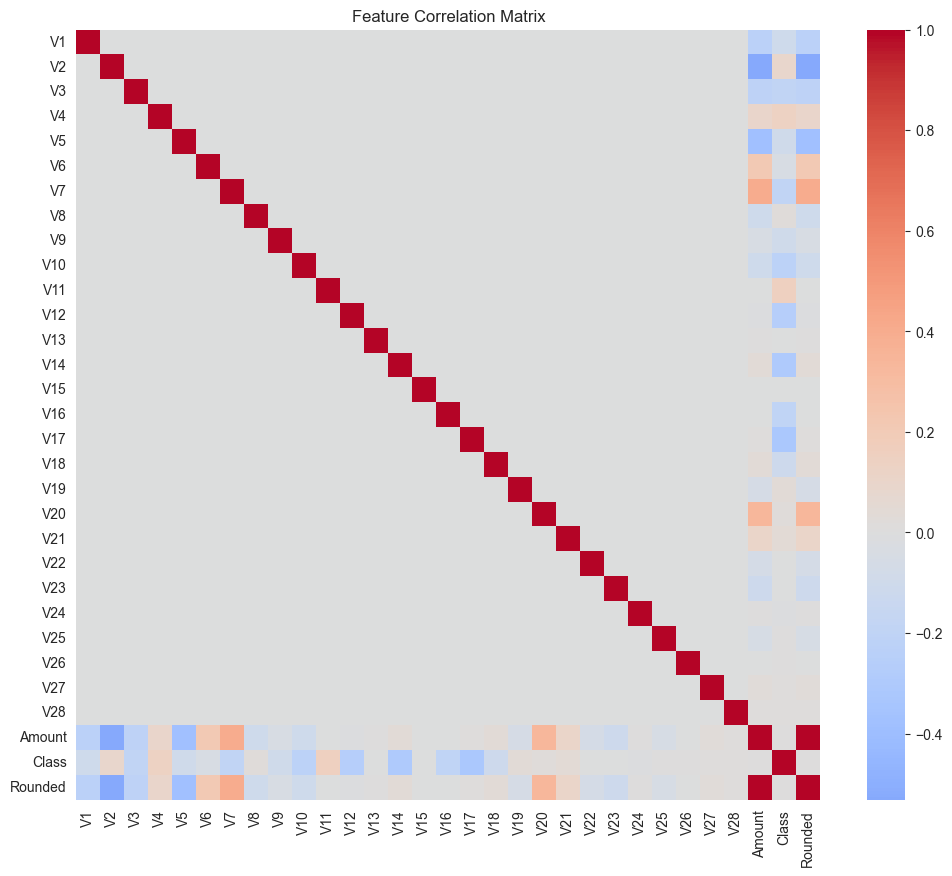

In [18]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

Perform Analysis Using Unsupervised Learning Models of your Choice, Present Discussion, and Conclusions (70 points)

Model building and training may depend on their data type(s) and task type(s). Depending on your project, you may have one model or more. Generally, it is deemed a higher quality project if you compare multiple models and show your understanding of why specific models work better than the other or what limitations or cautions specific models may have. When using multiple models, at least one of them should be an unsupervised approach.

 For machine learning models, another recommendation is to show enough effort on the hyperparameter optimization.

 If your project involves making a web app (not required), you can include the demo.

In [19]:
df[['Rounded']].describe()

,Rounded
count,284807.000000
mean,88.365500
std,250.116946
min,0.000000
25%,6.000000
50%,22.000000
75%,77.000000
max,25691.000000


Text(0.5, 1.0, 'PCA Projection of Transactions (colored by Class)')

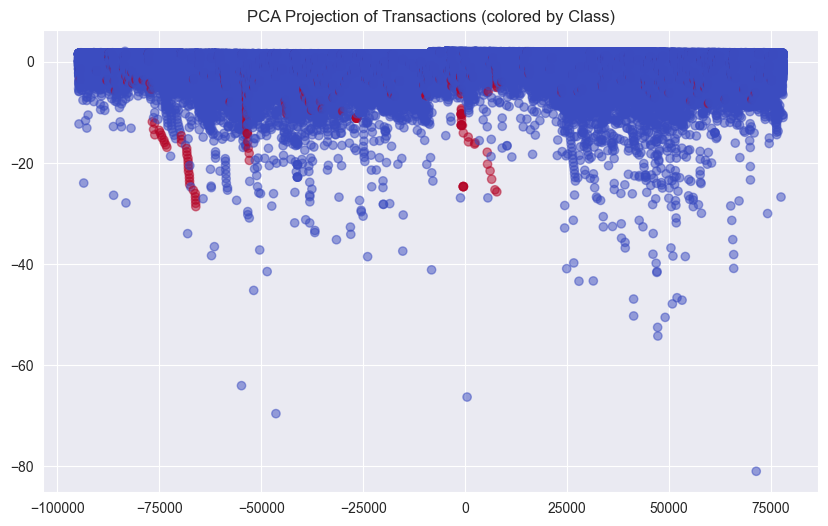

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.drop(columns='Class'))

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Class'], cmap='coolwarm', alpha=0.5)
plt.title("PCA Projection of Transactions (colored by Class)")


## Unsupervised Model 1 ##
Local Outlier Factor

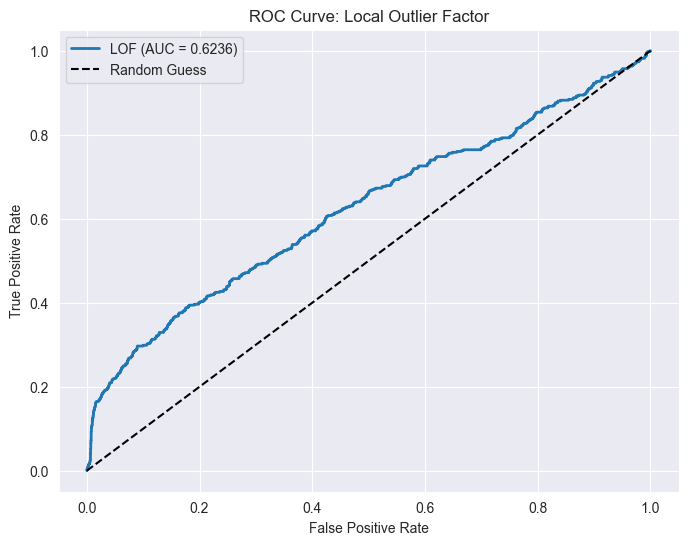

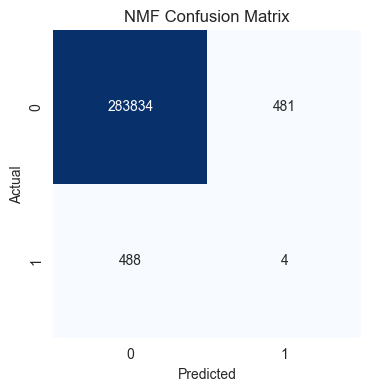


Classification Report:
              precision    recall  f1-score   support

           0     0.9983    0.9983    0.9983    284315
           1     0.0082    0.0081    0.0082       492

    accuracy                         0.9966    284807
   macro avg     0.5033    0.5032    0.5032    284807
weighted avg     0.9966    0.9966    0.9966    284807

ROC AUC Score: 0.5032191478906154
Precision: 0.008247422680412371
Recall: 0.008130081300813009


In [24]:
df = pd.read_csv('data/creditcard.csv.zip')
if 'Amount' in df:
   df['Amount_Norm'] = StandardScaler().fit_transform(df[['Amount']])
   df = df.drop(columns=['Amount'])
   #df = df.drop(columns=['Amount'])

# 4. Split features and target
if 'Class' in df:
   X = df.drop(columns=['Class'])

y_true = df['Class']



lof = LocalOutlierFactor(n_neighbors=200, contamination=0.0017, novelty=False)
y_pred = lof.fit_predict(X)  # Returns 1 (inlier) or -1 (outlier)

lof_scores = -lof.negative_outlier_factor_

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, lof_scores)
auc = roc_auc_score(y_true, lof_scores)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LOF (AUC = {auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Local Outlier Factor')
plt.legend()
plt.grid(True)
plt.show()

# 6. Convert to 0 (normal) and 1 (fraud)
y_pred = np.where(y_pred == -1, 1, 0)

# 7. Evaluation
cm =confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, square=True, cmap='Blues', fmt='.0f', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('NMF Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

print("ROC AUC Score:", roc_auc_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))


## Unsupervised Model 2 ##
IsolationForest

            Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V20       V21  \
0       0.462388  0.239599  0.098698  0.363787  ...  0.25141

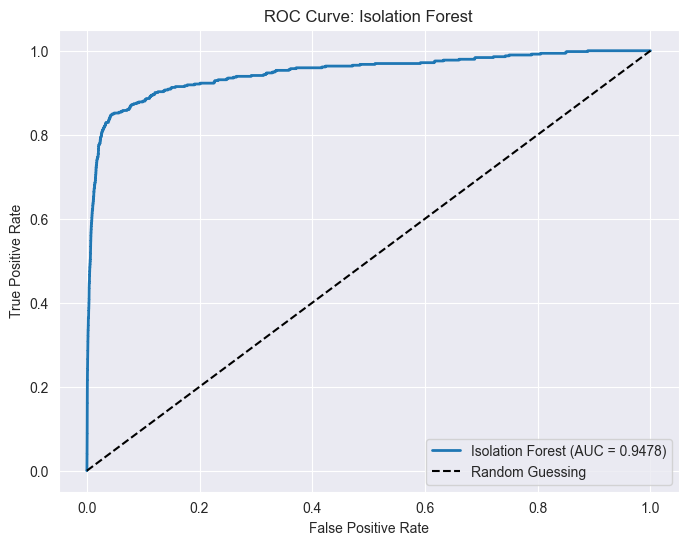

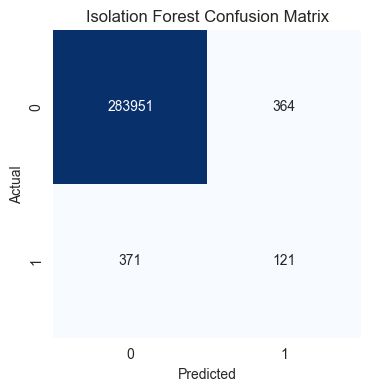


Classification Report:
              precision    recall  f1-score   support

           0     0.9987    0.9987    0.9987    284315
           1     0.2495    0.2459    0.2477       492

    accuracy                         0.9974    284807
   macro avg     0.6241    0.6223    0.6232    284807
weighted avg     0.9974    0.9974    0.9974    284807

ROC AUC Score: 0.6223273446133332
Precision: 0.24948453608247423
Recall: 0.2459349593495935


In [31]:
df = pd.read_csv('data/creditcard.csv.zip')
df['Amount_Norm'] = StandardScaler().fit_transform(df[['Amount']])
df = df.drop(columns=[ 'Amount'])

# 4. Define features (unsupervised — we won’t use 'Class' during training)
X = df.drop(columns=['Class'])
print(X)
y_true = df['Class']

# 5. Fit Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.0017, random_state=42)
y_pred = iso_forest.fit_predict(X)


scores = -iso_forest.decision_function(X)

# Get ROC curve
fpr, tpr, thresholds = roc_curve(y_true, scores)
auc = roc_auc_score(y_true, scores)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Isolation Forest (AUC = {auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Isolation Forest')
plt.legend()
plt.grid(True)
plt.show()


# 6. Convert Isolation Forest output to binary (1: normal, -1: anomaly)
y_pred = np.where(y_pred == -1, 1, 0)  # 1 = fraud prediction

# 7. Evaluation


cm =confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, square=True, cmap='Blues', fmt='.0f', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Isolation Forest Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

print("ROC AUC Score:", roc_auc_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))

# Hyperparameter Tuning on Isolation Forest #
Having determined that Isolation Forest is more effect at identifying fraud than LOC, I will now attempt to improve my results through attempting several levels of estimators




Best AUC: 0.9477983740409305
Best estimator: 50


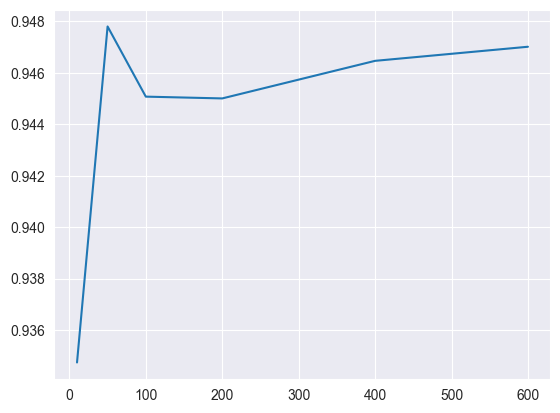

In [37]:
df = pd.read_csv('data/creditcard.csv.zip')
df['Amount_Norm'] = StandardScaler().fit_transform(df[['Amount']])
df = df.drop(columns=[ 'Amount'])
X = df.drop(columns=['Class'])
y_true = df['Class']

estimators = [10,  50, 100,200,400,600]

aucs = []
best_auc = 0
best_estimator = 0

for estimator in estimators:
    iso_forest = IsolationForest(n_estimators=estimator, contamination=0.0017, random_state=42)
    y_pred = iso_forest.fit_predict(X)
    scores = -iso_forest.decision_function(X)
    auc = roc_auc_score(y_true, scores)
    #auc = roc_auc_score(y_true, y_pred)
    aucs.append(auc)
    if auc > best_auc:
        best_auc = auc
        best_estimator = estimator

print("Best AUC:", best_auc)
print("Best estimator:", best_estimator)

plt.plot(estimators,aucs)


# Optimized Isolation Forest Results #

Using the optimal estimator value of 400, I recalculate the AUC






            Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V20       V21  \
0       0.462388  0.239599  0.098698  0.363787  ...  0.25141

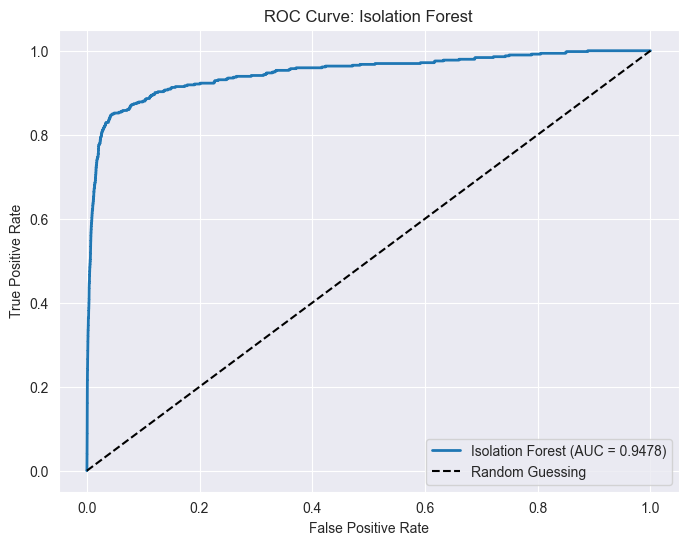

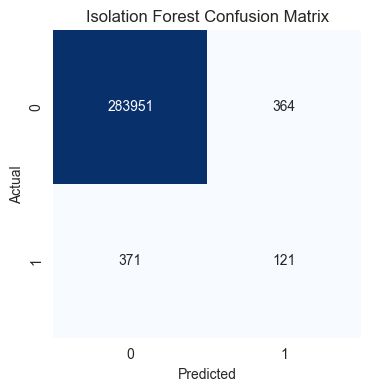


Classification Report:
              precision    recall  f1-score   support

           0     0.9987    0.9987    0.9987    284315
           1     0.2495    0.2459    0.2477       492

    accuracy                         0.9974    284807
   macro avg     0.6241    0.6223    0.6232    284807
weighted avg     0.9974    0.9974    0.9974    284807

ROC AUC Score: 0.6223273446133332
Precision: 0.24948453608247423
Recall: 0.2459349593495935


In [38]:
df = pd.read_csv('data/creditcard.csv.zip')
df['Amount_Norm'] = StandardScaler().fit_transform(df[['Amount']])
df = df.drop(columns=[ 'Amount'])

# 4. Define features (unsupervised — we won’t use 'Class' during training)
X = df.drop(columns=['Class'])
print(X)
y_true = df['Class']

# 5. Fit Isolation Forest
iso_forest = IsolationForest(n_estimators=50, contamination=0.0017, random_state=42)
y_pred = iso_forest.fit_predict(X)


scores = -iso_forest.decision_function(X)

# Get ROC curve
fpr, tpr, thresholds = roc_curve(y_true, scores)
auc = roc_auc_score(y_true, scores)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Isolation Forest (AUC = {auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Isolation Forest')
plt.legend()
plt.grid(True)
plt.show()


# 6. Convert Isolation Forest output to binary (1: normal, -1: anomaly)
y_pred = np.where(y_pred == -1, 1, 0)  # 1 = fraud prediction

# 7. Evaluation


cm =confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, square=True, cmap='Blues', fmt='.0f', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Isolation Forest Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

print("ROC AUC Score:", roc_auc_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))

# VS. SUPERVISED LEARNING #
Random Forest




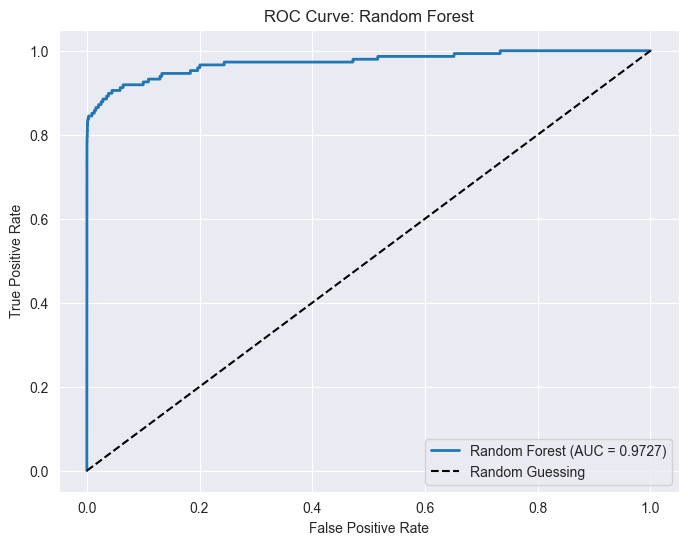

In [40]:
df = pd.read_csv('data/creditcard.csv.zip')
# Normalize 'Amount', drop 'Time'
df['Amount_Norm'] = StandardScaler().fit_transform(df[['Amount']])
df = df.drop(columns=['Time', 'Amount'])

# Features and labels
X = df.drop(columns=['Class'])
y = df['Class']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',  # handle imbalance
    random_state=42
)
rf.fit(X_train, y_train)

# Predict probabilities for the positive class
y_scores = rf.predict_proba(X_test)[:, 1]  # probability of fraud (class 1)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Random Forest')
plt.legend()
plt.grid(True)
plt.show()

# Conclusion #

Utilizing Unsupervised Learning methods to identify credit card fraud was effective, but did not out perform the Supervised Learning method.

This is not surprising since the Unsupervised Learning Model did not have the advantage of the class value to work with. However, it was surprisingly effective none-the-less and would be very useful in situations where the class value is unavailable, such as real-time analysis when the fraudulent activity has not yet been identified.
